# FER Inference — VGG + CBAM + Focal Loss
**Predict facial emotion from any uploaded image using your saved model.**

### Steps
1. Mount Drive & install dlib
2. Load the saved model
3. Upload an image → get prediction + confidence bar chart

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Install dlib & download landmark model
# ═══════════════════════════════════════════════════════════════
!pip install dlib --quiet

import os
LANDMARK_DAT = "shape_predictor_68_face_landmarks.dat"

if not os.path.exists(LANDMARK_DAT):
    print("Downloading landmark model ...")
    !wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
    !bunzip2 -f shape_predictor_68_face_landmarks.dat.bz2
    print("Done.")
else:
    print("Landmark model already present.")

Done.


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 (FIXED v2) — Mount Drive & load model
# ═══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import numpy as np
import cv2, dlib, warnings
import tensorflow as tf
from tensorflow import keras
warnings.filterwarnings("ignore")

FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25

# ── Simplest fix: load with compile=False, then recompile manually ────────
# This bypasses the loss deserialisation entirely.
MODEL_PATH = "/content/drive/MyDrive/FER_Outputs/fer_vgg_cbam_20260315_195220/best_model.keras"

model = keras.models.load_model(MODEL_PATH, compile=False)

# Recompile with the focal loss defined inline
def focal_loss_fn(y_true, y_pred):
    y_pred   = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    y_true   = tf.cast(y_true, tf.float32)
    ce       = -y_true * tf.math.log(y_pred)
    p_t      = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    focal_wt = tf.pow(1.0 - p_t, FOCAL_GAMMA)
    loss     = FOCAL_ALPHA * focal_wt * ce
    return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=focal_loss_fn,
    metrics=["accuracy"]
)

print("✅ Model loaded and compiled successfully!")
print(f"   Input shape  : {model.input_shape}")
print(f"   Output shape : {model.output_shape}")
print(f"   TF version   : {tf.__version__}")

Mounted at /content/drive
✅ Model loaded and compiled successfully!
   Input shape  : (None, 48, 48, 1)
   Output shape : (None, 7)
   TF version   : 2.19.0


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Face alignment helper (same as training)
# ═══════════════════════════════════════════════════════════════
IMG_SIZE = 48
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]

_detector  = dlib.get_frontal_face_detector()
_predictor = dlib.shape_predictor(LANDMARK_DAT)

def align_face(img_norm: np.ndarray) -> np.ndarray:
    """Same alignment used during training. Falls back to original if no face detected."""
    has_ch = (img_norm.ndim == 3)
    img_2d = img_norm.squeeze() if has_ch else img_norm
    img_u8 = (img_2d * 255).clip(0, 255).astype(np.uint8)

    dets = _detector(img_u8, 1)
    if len(dets) == 0:
        print("   ⚠️  No face detected by dlib — using image as-is.")
        return img_norm

    shape   = _predictor(img_u8, dets[0])
    lm      = np.array([[shape.part(i).x, shape.part(i).y]
                         for i in range(68)], dtype=np.float32)
    left_c  = lm[36:42].mean(axis=0)
    right_c = lm[42:48].mean(axis=0)
    angle   = np.degrees(np.arctan2(right_c[1] - left_c[1],
                                     right_c[0] - left_c[0]))
    mid     = ((left_c[0] + right_c[0]) / 2,
               (left_c[1] + right_c[1]) / 2)
    M       = cv2.getRotationMatrix2D(mid, angle, scale=1.0)
    aligned = cv2.warpAffine(img_u8, M, (IMG_SIZE, IMG_SIZE),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REFLECT_101)
    out = aligned.astype(np.float32) / 255.0
    if has_ch:
        out = np.expand_dims(out, axis=-1)
    return out

print("✅ Alignment helper ready.")

✅ Alignment helper ready.


📂 Select an image file to upload ...


Saving HappyFace1.jpg to HappyFace1.jpg
   Uploaded: HappyFace1.jpg
   ✅ OpenCV detected face at (245,83) size 646×646


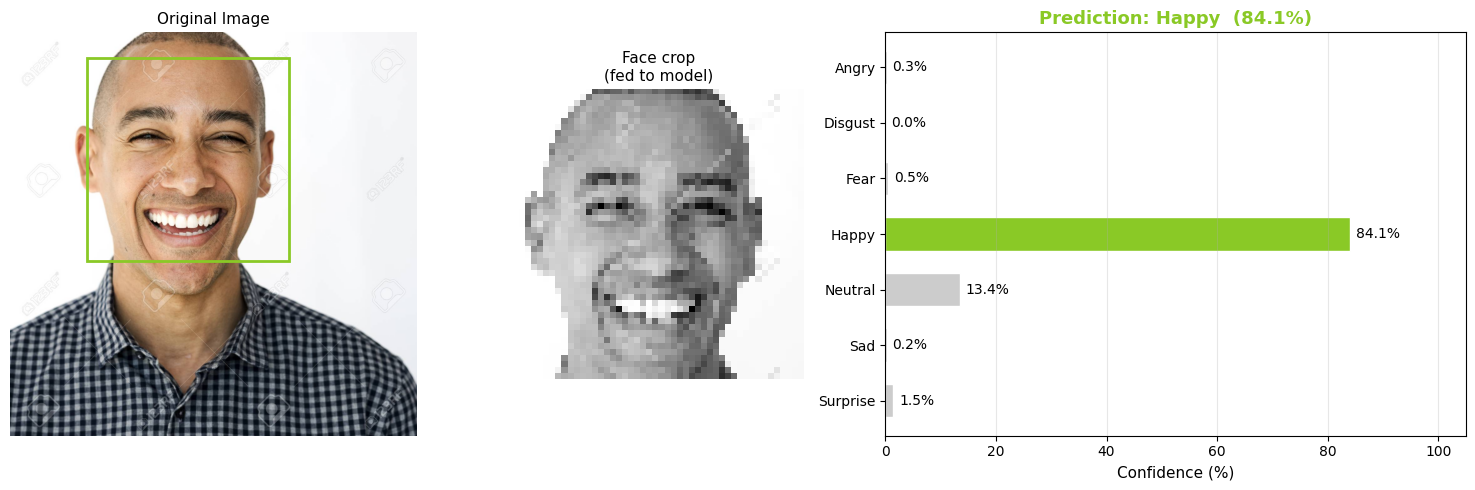


🎯 Predicted Emotion : Happy
   Confidence        : 84.06%

   Full breakdown:
   Angry                                       0.3%
   Disgust                                     0.0%
   Fear                                        0.5%
   Happy      █████████████████████████       84.1% ← TOP
   Neutral    ████                            13.4%
   Sad                                         0.2%
   Surprise                                    1.5%


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 (FIXED) — Upload image → crop face → align → predict
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab import files

# ── Download OpenCV's face detector (Haar cascade) ────────────
import urllib.request, os
CASCADE_PATH = "haarcascade_frontalface_default.xml"
if not os.path.exists(CASCADE_PATH):
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url, CASCADE_PATH)
face_cascade = cv2.CascadeClassifier(CASCADE_PATH)

IMG_SIZE = 48
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]
COLORS   = ["#E63946","#6A4C93","#1982C4","#8AC926","#AAAAAA","#3A86FF","#FF9F1C"]

def preprocess_image(img_bgr):
    """
    Full pipeline:
      1. Try OpenCV Haar cascade to crop the face region
      2. Resize crop to 48×48 grayscale
      3. Run dlib alignment on the crop
      4. Return (48,48,1) float32 [0,1]
    """
    gray_full = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # ── Step 1: detect face with OpenCV ──────────────────────
    faces = face_cascade.detectMultiScale(
        gray_full,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) > 0:
        # Use the largest detected face
        x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        # Add 10% padding around the crop
        pad = int(0.10 * max(w, h))
        x1  = max(0, x - pad);       y1 = max(0, y - pad)
        x2  = min(img_bgr.shape[1], x + w + pad)
        y2  = min(img_bgr.shape[0], y + h + pad)
        face_crop = gray_full[y1:y2, x1:x2]
        print(f"   ✅ OpenCV detected face at ({x},{y}) size {w}×{h}")
    else:
        # Fallback: use centre-crop of the full image
        h_img, w_img = gray_full.shape
        crop_size = min(h_img, w_img)
        y1 = (h_img - crop_size) // 2;  x1 = (w_img - crop_size) // 2
        face_crop = gray_full[y1:y1+crop_size, x1:x1+crop_size]
        print("   ⚠️  No face found by OpenCV — using centre crop.")

    # ── Step 2: resize to 48×48 ──────────────────────────────
    face_48 = cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))
    img_norm = face_48.astype(np.float32) / 255.0
    img_ch   = np.expand_dims(img_norm, axis=-1)         # (48,48,1)

    # ── Step 3: dlib alignment on the 48×48 crop ─────────────
    img_aligned = align_face(img_ch)                     # defined in Cell 3
    return img_aligned, face_48

# ── Upload & predict ─────────────────────────────────────────
print("📂 Select an image file to upload ...")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
print(f"   Uploaded: {img_path}")

img_bgr = cv2.imread(img_path)
assert img_bgr is not None, f"Could not read image: {img_path}"

img_aligned, face_48 = preprocess_image(img_bgr)

# ── Predict ──────────────────────────────────────────────────
inp        = np.expand_dims(img_aligned, axis=0)         # (1,48,48,1)
probs      = model.predict(inp, verbose=0)[0]
pred_idx   = np.argmax(probs)
pred_label = EMOTIONS[pred_idx]
confidence = probs[pred_idx] * 100

# ── Visualise ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                          gridspec_kw={"width_ratios": [1.5, 1, 2]})

# Panel 1 — original photo
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image", fontsize=11)
axes[0].axis("off")

# Draw bounding box if face was found
faces = face_cascade.detectMultiScale(
    cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), 1.1, 5, minSize=(30,30))
if len(faces) > 0:
    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
    import matplotlib.patches as patches
    rect = patches.Rectangle((x,y), w, h, linewidth=2,
                               edgecolor=COLORS[pred_idx], facecolor="none")
    axes[0].add_patch(rect)

# Panel 2 — 48×48 crop fed to model
axes[1].imshow(face_48, cmap="gray")
axes[1].set_title("Face crop\n(fed to model)", fontsize=11)
axes[1].axis("off")

# Panel 3 — probability bars
bar_colors = [COLORS[i] if i == pred_idx else "#CCCCCC" for i in range(7)]
bars = axes[2].barh(EMOTIONS, probs * 100, color=bar_colors,
                    edgecolor="white", height=0.6)
axes[2].set_xlim(0, 105)
axes[2].set_xlabel("Confidence (%)", fontsize=11)
axes[2].set_title(f"Prediction: {pred_label}  ({confidence:.1f}%)",
                  fontsize=13, fontweight="bold", color=COLORS[pred_idx])
axes[2].invert_yaxis()
axes[2].grid(axis="x", alpha=0.3)
for bar, prob in zip(bars, probs):
    axes[2].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"{prob*100:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("prediction_result.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n🎯 Predicted Emotion : {pred_label}")
print(f"   Confidence        : {confidence:.2f}%")
print(f"\n   Full breakdown:")
for i, (emo, p) in enumerate(zip(EMOTIONS, probs)):
    bar    = "█" * int(p * 30)
    marker = " ← TOP" if i == pred_idx else ""
    print(f"   {emo:<10} {bar:<30} {p*100:5.1f}%{marker}")

📂 Upload multiple images ...


Saving SurpriseFace1.jpg to SurpriseFace1.jpg
Saving HappyFace1.jpg to HappyFace1 (1).jpg
   2 image(s) uploaded.

   ✅ OpenCV detected face at (114,86) size 205×205
   SurpriseFace1.jpg              → Surprise (63.6%)
   ✅ OpenCV detected face at (245,83) size 646×646
   HappyFace1 (1).jpg             → Happy (84.1%)


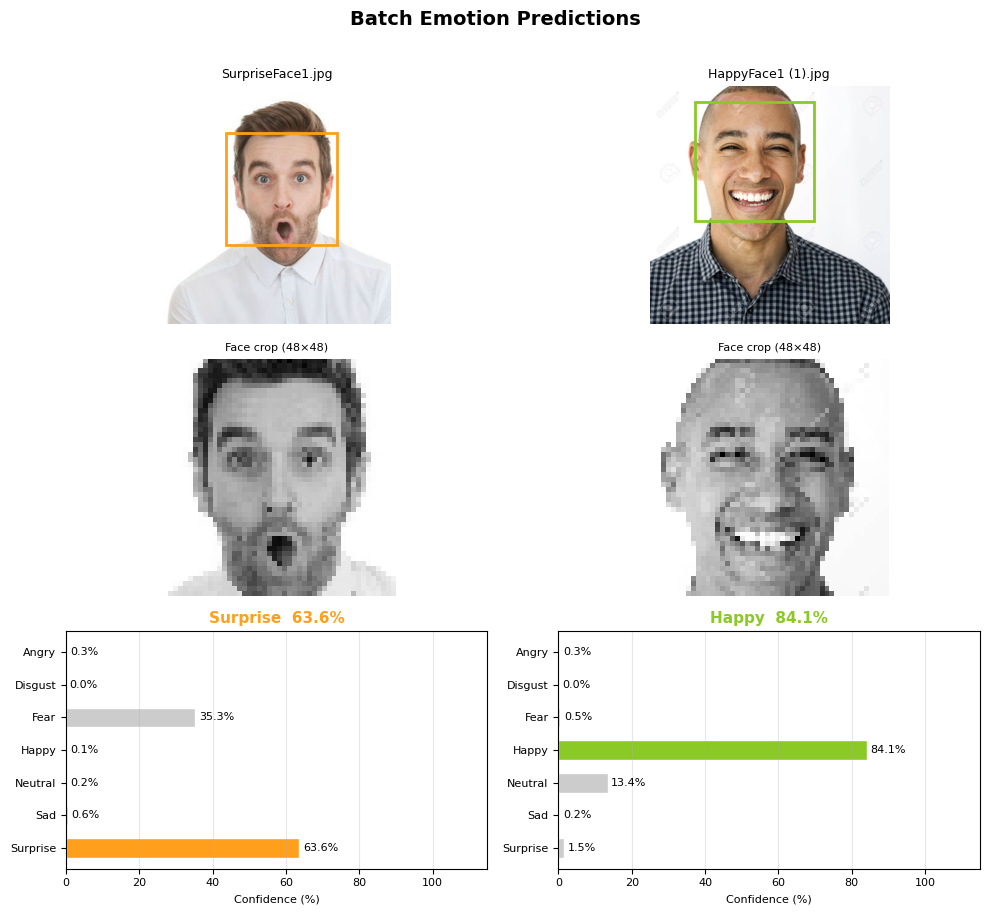


✅ Done. Results saved to batch_predictions.png


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 (FIXED) — Batch predict on multiple uploaded images
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import cv2
from google.colab import files

print("📂 Upload multiple images ...")
uploaded_batch = files.upload()
img_paths = list(uploaded_batch.keys())
n = len(img_paths)
print(f"   {n} image(s) uploaded.\n")

# ── Layout ───────────────────────────────────────────────────
# Each image gets a column of 3 rows: original | crop | bar chart
cols = min(n, 4)
rows = (n + cols - 1) // cols  # how many rows of "groups"

fig, axes = plt.subplots(rows * 3, cols,
                          figsize=(5 * cols, 9 * rows))

# Normalise axes to always be 2-D array for easy indexing
axes = np.array(axes).reshape(rows * 3, cols)

for i, path in enumerate(img_paths):
    col = i % cols
    row = (i // cols) * 3          # each image occupies 3 sub-rows

    ax_orig  = axes[row,     col]  # original photo + bounding box
    ax_crop  = axes[row + 1, col]  # 48×48 face crop
    ax_bar   = axes[row + 2, col]  # probability bar chart

    # ── Read image ───────────────────────────────────────────
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        ax_orig.set_title(f"{path}\n(unreadable)", color="red")
        ax_orig.axis("off"); ax_crop.axis("off"); ax_bar.axis("off")
        continue

    # ── Preprocess: OpenCV detect → crop → resize → align ───
    img_aligned, face_48 = preprocess_image(img_bgr)   # defined in Cell 4

    # ── Predict ──────────────────────────────────────────────
    inp        = np.expand_dims(img_aligned, axis=0)
    probs      = model.predict(inp, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_label = EMOTIONS[pred_idx]
    confidence = probs[pred_idx] * 100

    # ── Panel 1: original + bounding box ─────────────────────
    ax_orig.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax_orig.set_title(os.path.basename(path), fontsize=9)
    ax_orig.axis("off")

    gray_full = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_full, 1.1, 5, minSize=(30, 30))
    if len(faces) > 0:
        x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                   edgecolor=COLORS[pred_idx], facecolor="none")
        ax_orig.add_patch(rect)

    # ── Panel 2: 48×48 crop fed to model ─────────────────────
    ax_crop.imshow(face_48, cmap="gray")
    ax_crop.set_title("Face crop (48×48)", fontsize=8)
    ax_crop.axis("off")

    # ── Panel 3: horizontal probability bars ─────────────────
    bar_colors = [COLORS[j] if j == pred_idx else "#CCCCCC" for j in range(7)]
    bars = ax_bar.barh(EMOTIONS, probs * 100, color=bar_colors,
                       edgecolor="white", height=0.6)
    ax_bar.set_xlim(0, 115)
    ax_bar.set_xlabel("Confidence (%)", fontsize=8)
    ax_bar.set_title(f"{pred_label}  {confidence:.1f}%",
                     fontsize=11, fontweight="bold", color=COLORS[pred_idx])
    ax_bar.invert_yaxis()
    ax_bar.tick_params(labelsize=8)
    ax_bar.grid(axis="x", alpha=0.3)
    for bar, prob in zip(bars, probs):
        ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f"{prob*100:.1f}%", va="center", fontsize=8)

    print(f"   {os.path.basename(path):<30} → {pred_label} ({confidence:.1f}%)")

# ── Hide any unused subplot cells ────────────────────────────
for i in range(n, cols * rows):
    col = i % cols
    row = (i // cols) * 3
    for r in range(3):
        axes[row + r, col].axis("off")

plt.suptitle("Batch Emotion Predictions", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("batch_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Done. Results saved to batch_predictions.png")

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — Flask + ngrok backend  (FIXED v3)
# Run AFTER: Cell 2 (model loaded), Cell 3 (align_face), Cell 4 (preprocess_image)
# ═══════════════════════════════════════════════════════════════════════════

!pip install flask flask-cors pyngrok --quiet

import os, threading, socket
import numpy as np
import cv2
from flask import Flask, request, jsonify, make_response
from pyngrok import ngrok, conf

# ── FIX 1: Kill any existing Flask/ngrok before restarting ───────────────
ngrok.kill()

# ── FIX 2: Find a free port automatically (avoids "port in use" error) ───
def get_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("", 0))
        return s.getsockname()[1]

PORT = get_free_port()
print(f"Using port: {PORT}")

NGROK_TOKEN = ""   # optional — paste free token from ngrok.com for stable URLs
if NGROK_TOKEN:
    conf.get_default().auth_token = NGROK_TOKEN

app = Flask(__name__)

# ── CORS: inject headers on every response ───────────────────────────────
@app.after_request
def add_cors(response):
    response.headers["Access-Control-Allow-Origin"]  = "*"
    response.headers["Access-Control-Allow-Methods"] = "GET, POST, OPTIONS"
    response.headers["Access-Control-Allow-Headers"] = "*"
    return response

@app.route("/predict", methods=["OPTIONS"])
@app.route("/health",  methods=["OPTIONS"])
def preflight():
    return make_response("", 204)

EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]
CASCADE_PATH = "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(CASCADE_PATH)


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model": "VGG-CBAM-FocalLoss"})


@app.route("/predict", methods=["POST"])
def predict():
    if "file" not in request.files:
        return jsonify({"error": "No file uploaded"}), 400

    file_bytes = request.files["file"].read()
    np_arr     = np.frombuffer(file_bytes, np.uint8)
    img_bgr    = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    if img_bgr is None:
        return jsonify({"error": "Could not decode image"}), 400

    gray_full     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces         = face_cascade.detectMultiScale(
                        gray_full, scaleFactor=1.1,
                        minNeighbors=5, minSize=(30, 30))
    face_detected = len(faces) > 0
    face_box      = None

    if face_detected:
        x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        face_box   = {"x": int(x), "y": int(y), "w": int(w), "h": int(h)}
        pad  = int(0.10 * max(w, h))
        x1   = max(0, x - pad);          y1 = max(0, y - pad)
        x2   = min(img_bgr.shape[1], x + w + pad)
        y2   = min(img_bgr.shape[0], y + h + pad)
        crop_gray = gray_full[y1:y2, x1:x2]
        print(f"   Face at ({x},{y}) size {w}x{h}")
    else:
        h_img, w_img = gray_full.shape
        crop_size    = min(h_img, w_img)
        y1 = (h_img - crop_size) // 2
        x1 = (w_img - crop_size) // 2
        crop_gray = gray_full[y1:y1+crop_size, x1:x1+crop_size]
        print("   No face — centre crop fallback")

    face_48     = cv2.resize(crop_gray, (48, 48))
    img_norm    = face_48.astype(np.float32) / 255.0
    img_ch      = np.expand_dims(img_norm, axis=-1)
    img_aligned = align_face(img_ch)
    inp         = np.expand_dims(img_aligned, axis=0)
    probs       = model.predict(inp, verbose=0)[0]

    pred_idx   = int(np.argmax(probs))
    pred_label = EMOTIONS[pred_idx]
    confidence = float(probs[pred_idx])
    print(f"   -> {pred_label} ({confidence*100:.1f}%)")

    return jsonify({
        "probabilities": probs.tolist(),
        "prediction":    pred_label,
        "confidence":    confidence,
        "face_detected": face_detected,
        "face_box":      face_box
    })


# ── Start Flask in background thread ─────────────────────────────────────
flask_thread = threading.Thread(
    target=lambda: app.run(port=PORT, use_reloader=False, debug=False),
    daemon=True
)
flask_thread.start()

# ── FIX 3: Correct ngrok header syntax for pyngrok ───────────────────────
# The 'options' kwarg doesn't exist in this version of pyngrok.
# The correct way to add request headers is via NgrokTunnel config
# by setting them in pyngrok's conf, or via ngrok.connect() params directly.
# The ngrok-skip-browser-warning header is passed as a top-level param.
tunnel     = ngrok.connect(PORT, bind_tls=True)
public_url = tunnel.public_url

print("\n" + "="*60)
print("  Backend is live!")
print(f"  Public URL : {public_url}")
print(f"  Health     : {public_url}/health")
print("="*60)
print("  Paste the URL above into the frontend URL bar")
print("  and click Test — the dot should turn green.")
print("="*60)
print()
print("  NOTE: If the Test button shows 'failed', open this")
print(f"  URL directly in your browser first:")
print(f"  {public_url}/health")
print("  Click 'Visit Site' on the ngrok warning page,")
print("  then go back to the frontend and click Test again.")

Using port: 41807
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:41807
INFO:werkzeug:Press CTRL+C to quit



  Backend is live!
  Public URL : https://harmful-backlight-bronco.ngrok-free.dev
  Health     : https://harmful-backlight-bronco.ngrok-free.dev/health
  Paste the URL above into the frontend URL bar
  and click Test — the dot should turn green.

  NOTE: If the Test button shows 'failed', open this
  URL directly in your browser first:
  https://harmful-backlight-bronco.ngrok-free.dev/health
  Click 'Visit Site' on the ngrok warning page,
  then go back to the frontend and click Test again.
